# Day 08. Exercise 02
# Multiclass classification. One-hot encoding. Random forest

## 0. Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

## 1. Preprocessing

1. Read the file [`checker-submits.csv`](https://drive.google.com/file/d/14voc4fNJZiLEFaZyd8nEG-lQt5JjatYw/view?usp=sharing).
2. Create a dataframe `df` with the columns: `uid`, `labname`, `numTrials`, `hour`, `dayofweek` where `hour` is extracted from the `timestamp` as well as the `dayofweek` (`0` is Monday, `6` is Sunday). We will try to predict the day of the week having data about which user made a commit for which lab at which hour and which try it was.
3. Using `OneHotEncoder()` transform your categorical features, delete from the dataframe the initial columns.
4. Use `StandardScaler()` and scale your continuous features.
5. Save the dataframe as `dayofweek.csv`.
6. Before trying out different algorithms, find out the accuracy of the naive algorithms – the one that predicts everything as the most popular class.

In [ ]:
df = pd.read_csv('../data/checker_submits.csv')
df['timestamp'] = pd.to_datetime(df['timestamp'])

In [ ]:
# creating required columns 
df['hour'] = df['timestamp'].dt.hour
df['dayofweek'] = df['timestamp'].dt.weekday

df = df[['uid', 'labname', 'numTrials', 'hour', 'dayofweek']]

In [ ]:
# one-hot encoding
encoder = OneHotEncoder(sparse_output=False)
encoded = encoder.fit_transform(df[['uid', 'labname']])

encoded_df = pd.DataFrame(encoded, columns=encoder.get_feature_names_out())

df = pd.concat([df.drop(['uid', 'labname'], axis=1), encoded_df], axis=1)

In [ ]:
scaler = StandardScaler()
df[['numTrials', 'hour']] = scaler.fit_transform(df[['numTrials', 'hour']])

In [ ]:
#saving file
df.to_csv('../data/dayofweek.csv', index=False)

In [ ]:
most_common = df['dayofweek'].mode()[0]
df['naive'] = most_common

accuracy_naive = accuracy_score(df['dayofweek'], df['naive'])
print("Naive accuracy:", accuracy_naive)

Naive accuracy: 0.23487544483985764


## 2. Algorithms

### a. Logreg

1. Train logistic regression, for the baseline model use `random_state=21`, `fit_intercept=False`. 
2. Calculate the accuracy.
3. Write a function that draws the plot (`barh`) taking coefficients of any trained models, names of the features and the number of `top-n` most important features to display.
4. Draw a plot (`barh`) for the baseline model with top-10 most important features (absolute value) for the trained model.
5. Remember that it is a multiclass classification and `coef_` returns a matrix, to calculate importance for a feature you need to sum all the individual feature importances for all the target values.

In [ ]:
#training logistic regression
X = df.drop(['dayofweek'], axis=1)
y = df['dayofweek']

model = LogisticRegression(random_state=21, fit_intercept=False, max_iter=1000)
model.fit(X, y)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,False
,intercept_scaling,1
,class_weight,None
,random_state,21
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [ ]:
df['predict_logreg'] = model.predict(X)
accuracy_logreg = accuracy_score(y, df['predict_logreg'])
print("LogReg accuracy:", accuracy_logreg)

LogReg accuracy: 0.6405693950177936


In [ ]:
def plot_top_features(model, feature_names, top_n=10):
    coefs = np.abs(model.coef_)        # remove sign
    importance = coefs.sum(axis=0)     # combine classes

    indices = np.argsort(importance)[-top_n:]

    plt.figure(figsize=(10,6))
    plt.barh(range(top_n), importance[indices])
    plt.yticks(range(top_n), [feature_names[i] for i in indices])
    plt.title("Top features")
    plt.show()

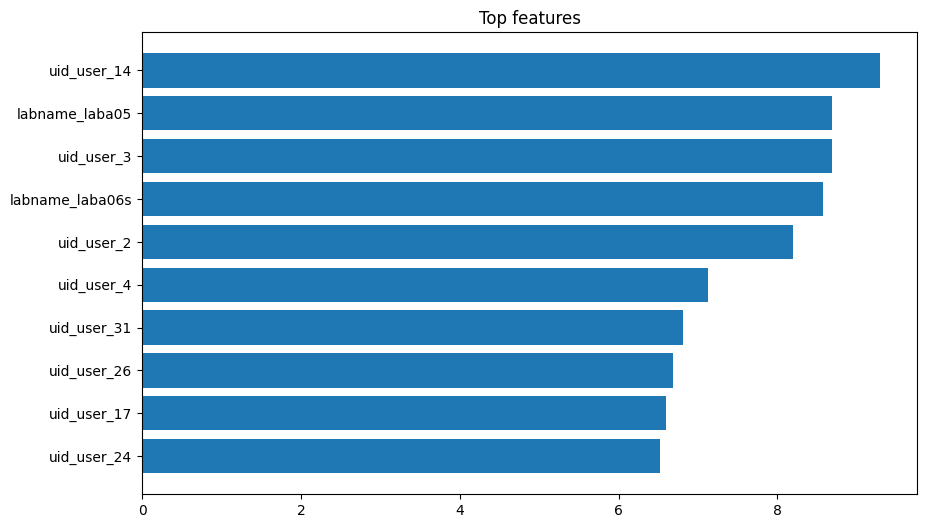

In [ ]:
plot_top_features(model, X.columns, 10)

### b. SVC

1. Train a `SVC` model, for the baseline model use parameters `kernel='linear'`, `probability=True`, `random_state=21`. 
2. Try different kernels, calculate the accuracies.
3. Draw a plot (`barh`) for the baseline model with top-10 most important features (absolute value) for the trained model for the linear kernel *

*By default SVC uses “one vs one” strategy of the classification, thus in `coef_` it returns a matrix. To calculate importance for a feature you need to use [OneVsRestClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.multiclass.OneVsRestClassifier.html) over the SVC and sum all the individual feature importances for all the target values.

In [ ]:
#training baseline SVC
svc = SVC(kernel='linear', probability=True, random_state=21)
svc.fit(X, y)

df['predict_svc'] = svc.predict(X)

In [ ]:
accuracy_svc = accuracy_score(y, df['predict_svc'])
print("SVC accuracy:", accuracy_svc)

SVC accuracy: 0.702846975088968


In [ ]:
for kernel in ['linear', 'rbf', 'poly']:
    model = SVC(kernel=kernel, probability=True, random_state=21)
    model.fit(X, y)
    pred = model.predict(X)
    acc = accuracy_score(y, pred)
    print(kernel, acc)

linear 0.702846975088968
rbf 0.7277580071174378
poly 0.767497034400949


In [ ]:
#featuring importance
ovr = OneVsRestClassifier(SVC(kernel='linear'))
ovr.fit(X, y)

,estimator,SVC(kernel='linear')
,n_jobs,None
,verbose,0
,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001


In [ ]:
#extracting features
coefs = np.array([est.coef_[0] for est in ovr.estimators_])
importance = np.abs(coefs).sum(axis=0)

In [ ]:
#plotting 
def plot_top_features_svc(importance, feature_names, top_n=10):
    indices = np.argsort(importance)[-top_n:]
    plt.figure(figsize=(10,6))
    plt.barh(range(top_n), importance[indices])
    plt.yticks(range(top_n), [feature_names[i] for i in indices])
    plt.title("Top SVC features")
    plt.show()

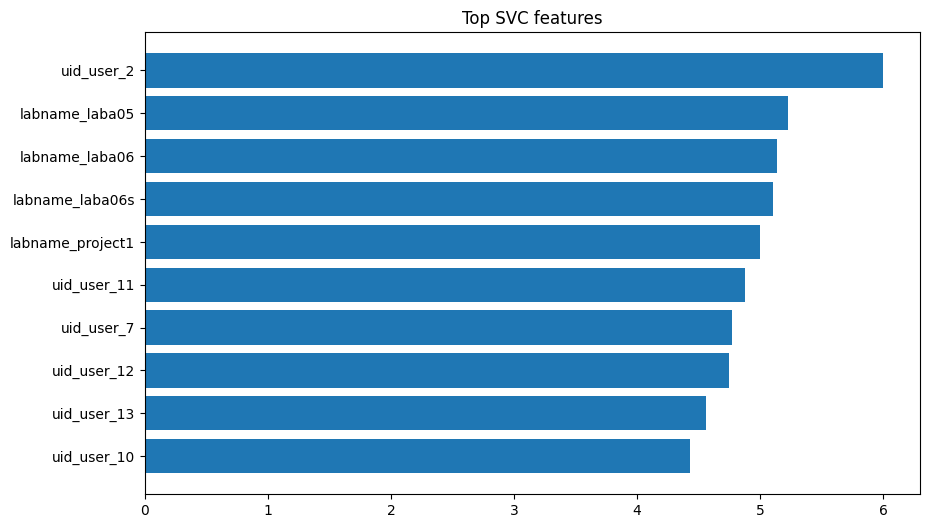

In [ ]:
plot_top_features_svc(importance, X.columns, 10)

### c. Decision tree

1. Train a `DecisionTreeClassifier` using for the baseline model `max_depth=4`, `random_state=21`. 
2. Try different values of `max_depth`, calculate the accuracies.
3. Draw a plot (`barh`) for the baseline model with top-10 most important features (absolute value) for the trained model using the written function.

In [ ]:
tree = DecisionTreeClassifier(max_depth=4, random_state=21)
tree.fit(X, y)

df['predict_tree'] = tree.predict(X)

In [ ]:
accuracy_tree = accuracy_score(y, df['predict_tree'])
print("Tree accuracy:", accuracy_tree)

Tree accuracy: 0.5516014234875445


In [ ]:
for d in [1,2,3,4,5,6]:
    model = DecisionTreeClassifier(max_depth=d, random_state=21)
    model.fit(X, y)
    pred = model.predict(X)
    acc = accuracy_score(y, pred)
    print(d, acc)

1 0.35765124555160144
2 0.4389086595492289
3 0.48991696322657174
4 0.5516014234875445
5 0.6109134045077106
6 0.6637010676156584


In [ ]:
importance = tree.feature_importances_

In [ ]:
def plot_top_features_from_importance(importance, feature_names, top_n=10):
    indices = np.argsort(importance)[-top_n:]

    plt.figure(figsize=(10,6))
    plt.barh(range(top_n), importance[indices])
    plt.yticks(range(top_n), [feature_names[i] for i in indices])
    plt.title("Top Decision Tree Features")
    plt.show()

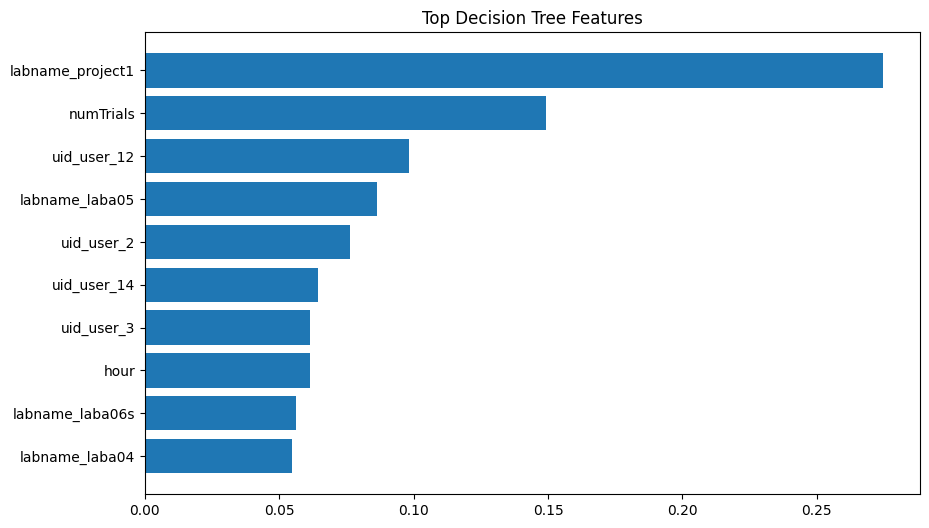

In [ ]:
plot_top_features_from_importance(importance, X.columns, 10)

### d. Random forest

In real life forest is a set of trees. The same thing is with machine learning. Random forest is a set of individual decision trees (check the documentation for more details).

1. Train a `RandomForestClassifier` using for the baseline model parameters `n_estimators=100`, `max_depth = 25`, `random_state=21`. 
2. Try different values of `max_depth` and `n_estimators`, calculate the accuracies.
3. Draw a plot (`barh`) for the baseline model with top-10 most important features (absolute value) for the trained model using the written function.

In [ ]:
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=25,
    random_state=21
)

rf.fit(X, y)

df['predict_rf'] = rf.predict(X)

accuracy_rf = accuracy_score(y, df['predict_rf'])
print("Random Forest accuracy:", accuracy_rf)

Random Forest accuracy: 1.0


In [ ]:
for depth in [5,10,15,25]:
    for n in [50,100,200]:
        model = RandomForestClassifier(
            n_estimators=n,
            max_depth=depth,
            random_state=21
        )
        model.fit(X, y)
        pred = model.predict(X)
        acc = accuracy_score(y, pred)
        print(f"depth={depth}, trees={n}, acc={acc}")

depth=5, trees=50, acc=0.594306049822064
depth=5, trees=100, acc=0.5871886120996441
depth=5, trees=200, acc=0.6103202846975089
depth=10, trees=50, acc=0.8677342823250297
depth=10, trees=100, acc=0.872479240806643
depth=10, trees=200, acc=0.8766310794780545
depth=15, trees=50, acc=0.9774614472123369
depth=15, trees=100, acc=0.9733096085409253
depth=15, trees=200, acc=0.9756820877817319
depth=25, trees=50, acc=1.0
depth=25, trees=100, acc=1.0
depth=25, trees=200, acc=1.0


In [ ]:
importance = rf.feature_importances_

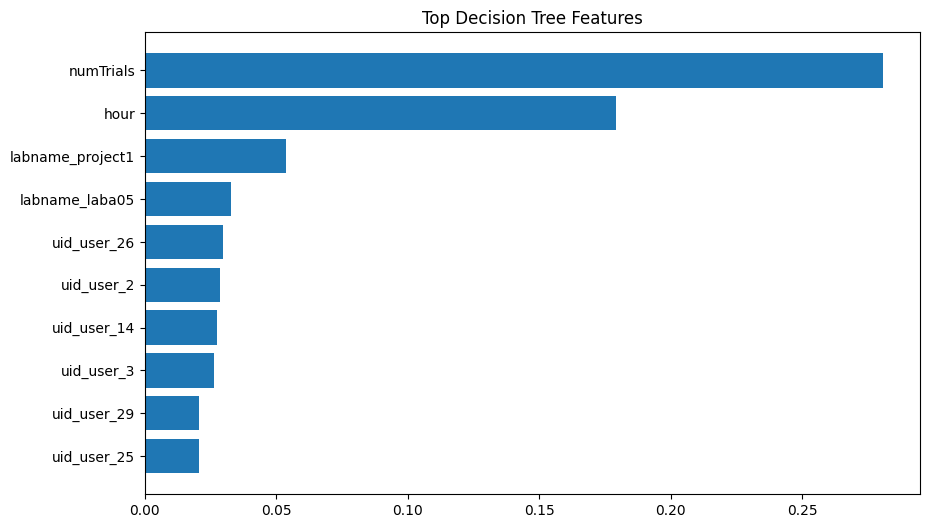

In [ ]:
plot_top_features_from_importance(importance, X.columns, 10)